
# Machine Learning–based Late Delivery Risk Prediction in Global Supply Chain Operations
#### APL Logistics

Raw dataset  : 180,519 rows × 40 columns

Duplicates   : 0
Missing cols : 2
Customer Lname      8
Customer Zipcode    3

Class balance — On-Time: 81,542  |  Late: 98,977  (54.8% late)


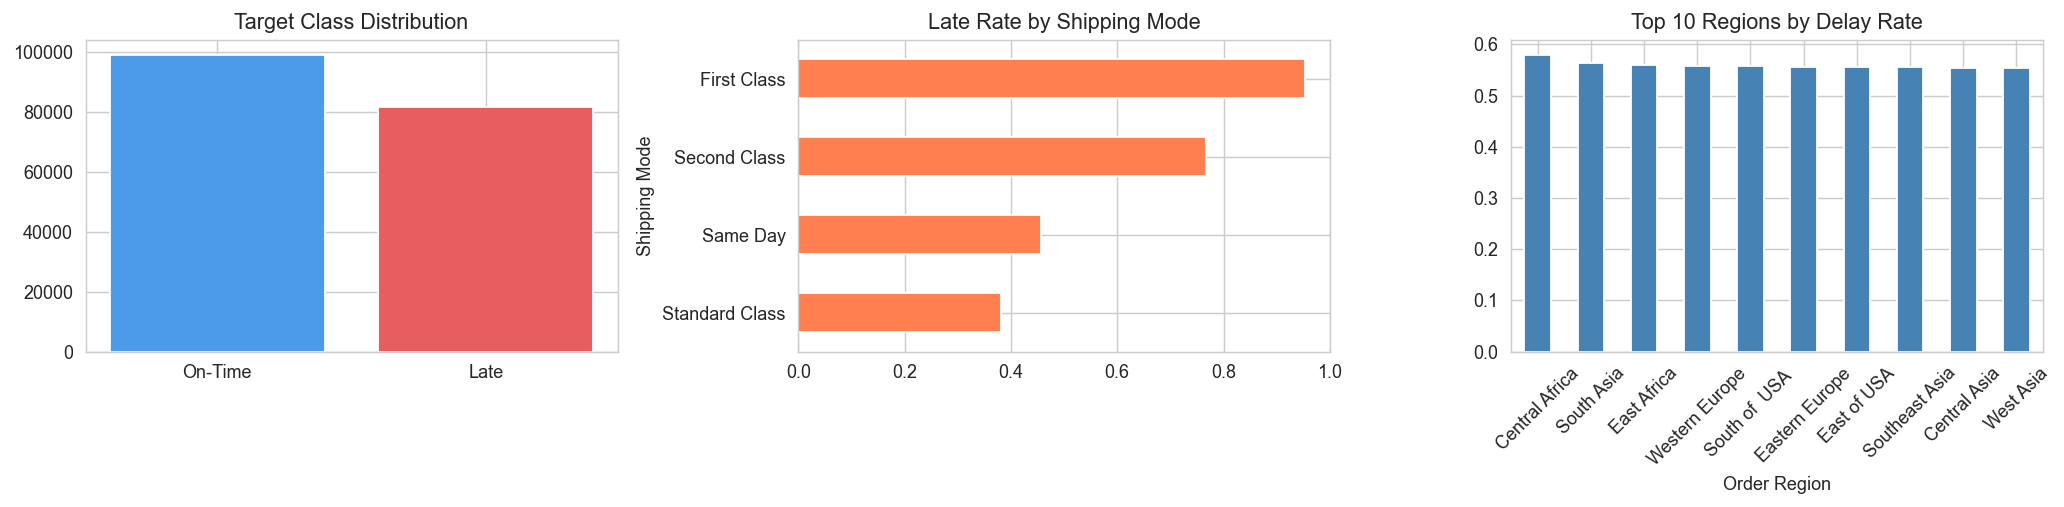


No date column found — using row order as temporal proxy.
If your dataset has a date column, map it in DATE_CANDIDATES above.

Chronological split — Train: 144,415  |  Test: 36,104
Train late rate: 54.8%  |  Test late rate: 55.1%

Feature matrix — Train: (144415, 64)  |  Test: (36104, 64)

  Time-Series Cross-Validation (ROC-AUC)
  Each fold: train on past → validate on future
  Logistic Regression      : 0.7657 ± 0.0044  [0.769, 0.758, 0.771, 0.765, 0.765]
  Random Forest            : 0.7631 ± 0.0064  [0.766, 0.752, 0.771, 0.760, 0.766]
  XGBoost                  : 0.7590 ± 0.0070  [0.752, 0.751, 0.769, 0.759, 0.765]


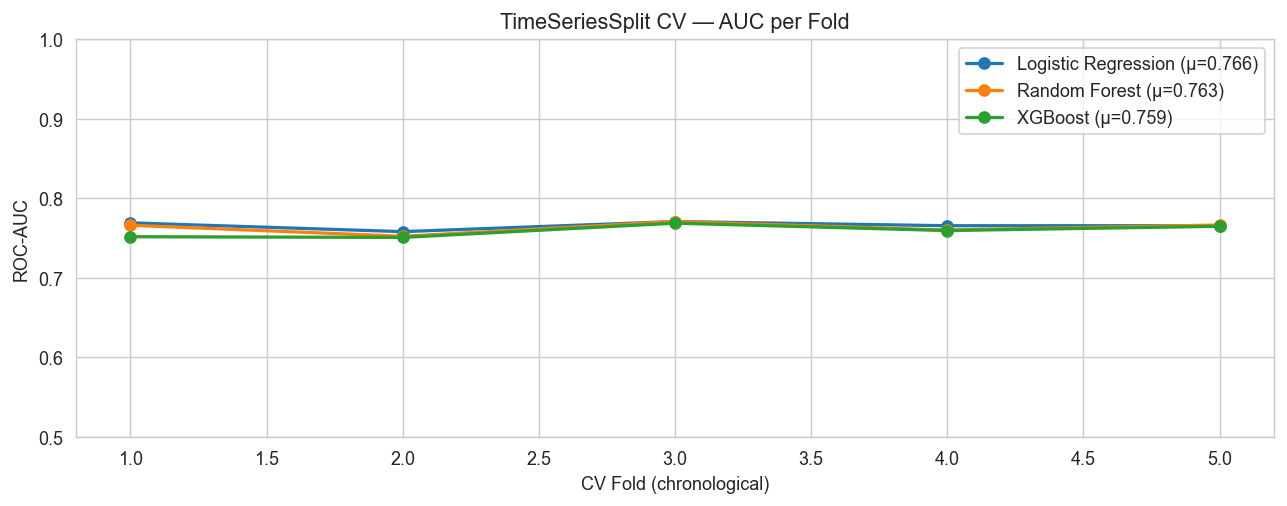


Fitting final models on full training partition...
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost

  Hold-Out Test Set Evaluation  (chronological 20%)

  Logistic Regression  (threshold = 0.35)
  ROC-AUC      : 0.6984
  F1 Score     : 0.7084
  Precision    : 0.6107
  Recall       : 0.8432
  Avg Precision: 0.7330

              precision    recall  f1-score   support

     On-Time      0.638     0.340     0.443     16201
        Late      0.611     0.843     0.708     19903

    accuracy                          0.617     36104
   macro avg      0.624     0.591     0.576     36104
weighted avg      0.623     0.617     0.589     36104


  Random Forest  (threshold = 0.35)
  ROC-AUC      : 0.7435
  F1 Score     : 0.7091
  Precision    : 0.6267
  Recall       : 0.8163
  Avg Precision: 0.8177

              precision    recall  f1-score   support

     On-Time      0.641     0.403     0.495     16201
        Late      0.627     0.816     0.709     19903

    accuracy                

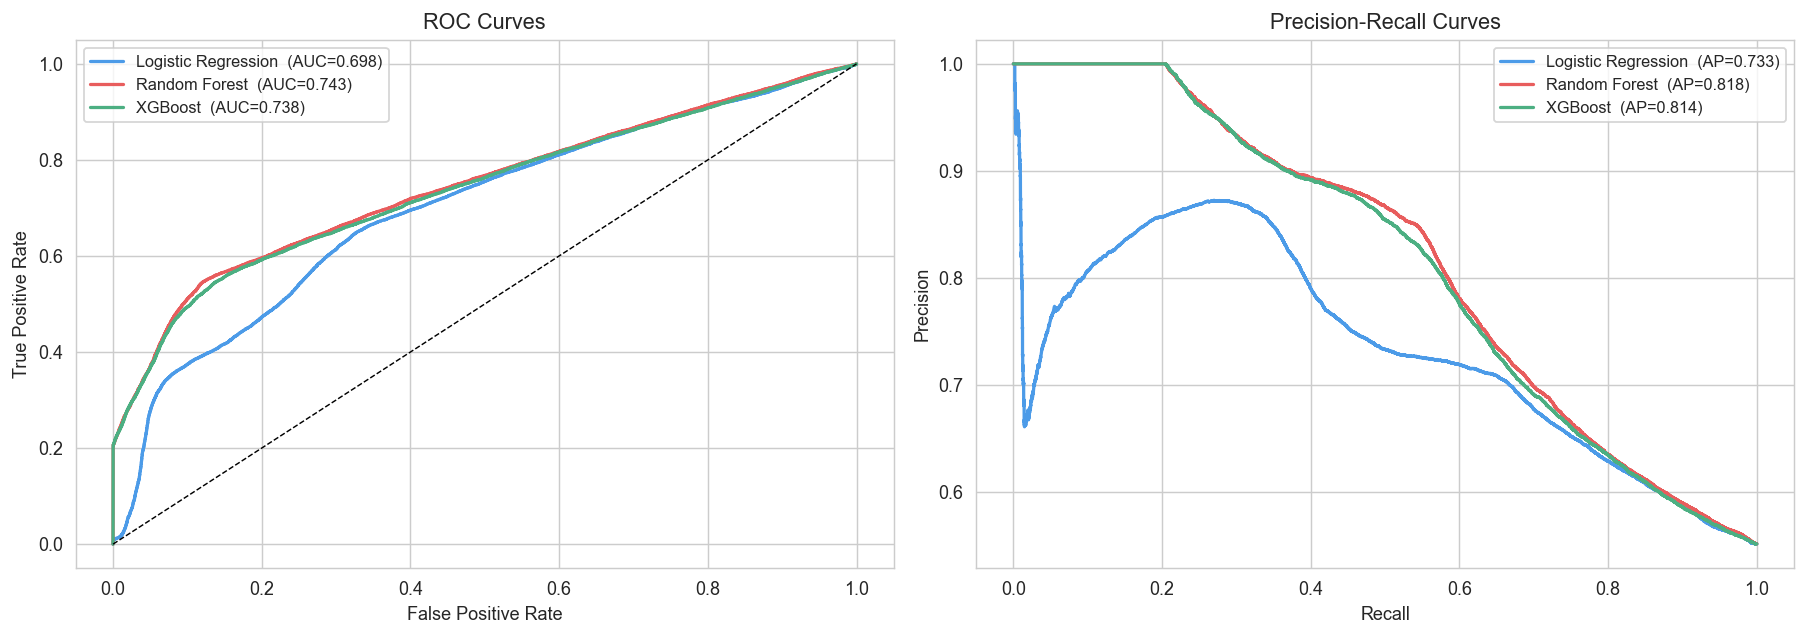

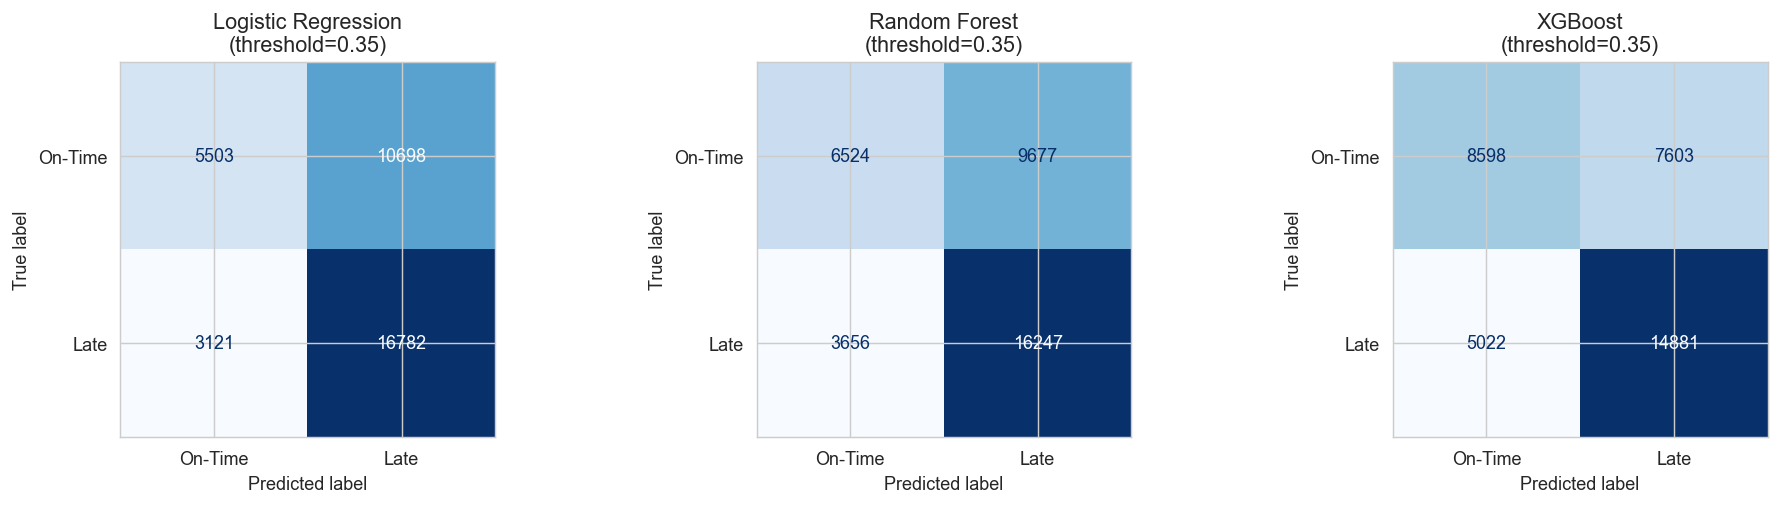


Best model: Random Forest — Threshold sensitivity:
   Threshold   Precision      Recall        F1   Flagged%
        0.25       0.553       0.995     0.711      99.2%
        0.30       0.570       0.948     0.712      91.7%
        0.35       0.627       0.816     0.709      71.8% ◀ selected
        0.40       0.734       0.652     0.690      49.0%
        0.45       0.790       0.592     0.677      41.3%
        0.50       0.827       0.564     0.671      37.6%


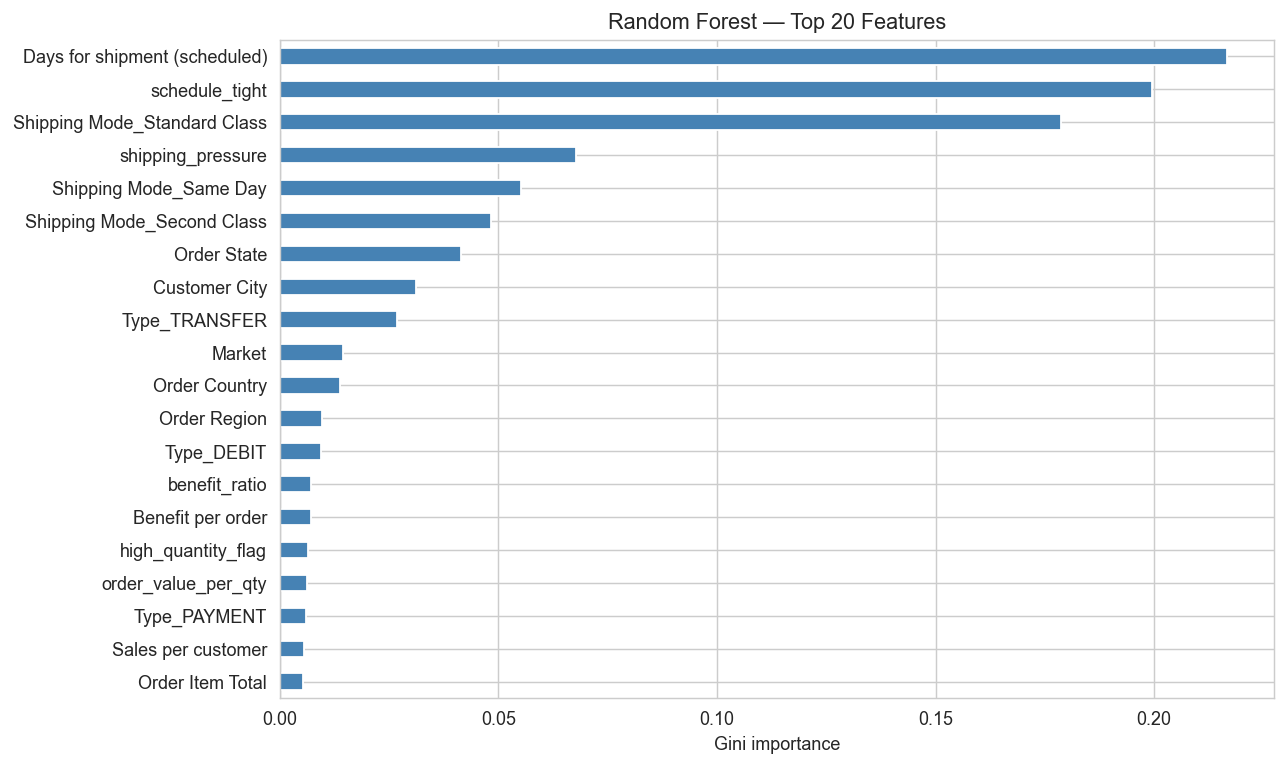


Top 10 Risk Drivers:
Days for shipment (scheduled)    0.216583
schedule_tight                   0.199505
Shipping Mode_Standard Class     0.178615
shipping_pressure                0.067652
Shipping Mode_Same Day           0.055272
Shipping Mode_Second Class       0.048320
Order State                      0.041376
Customer City                    0.031068
Type_TRANSFER                    0.026723
Market                           0.014533


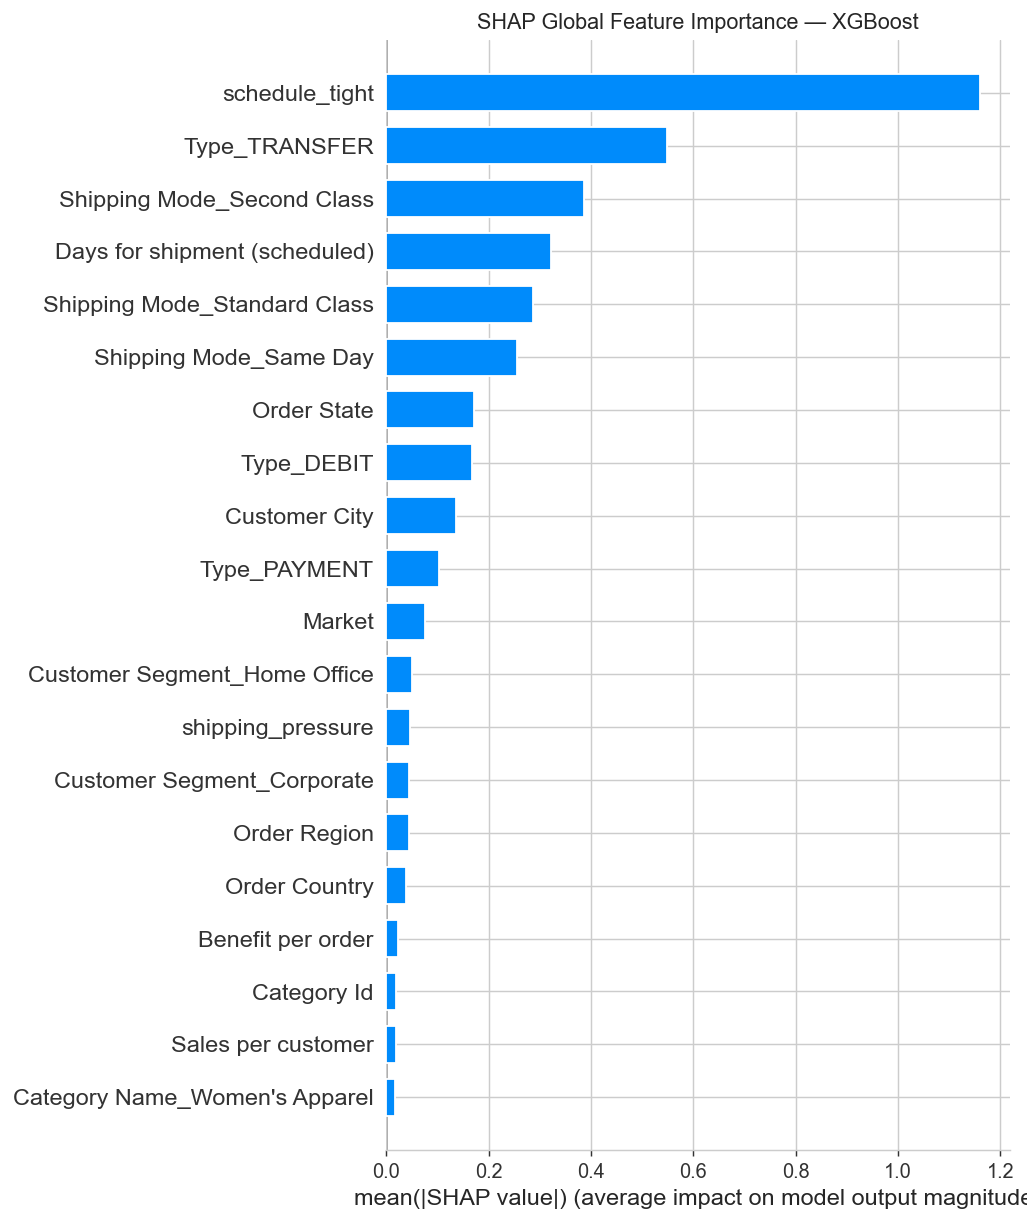

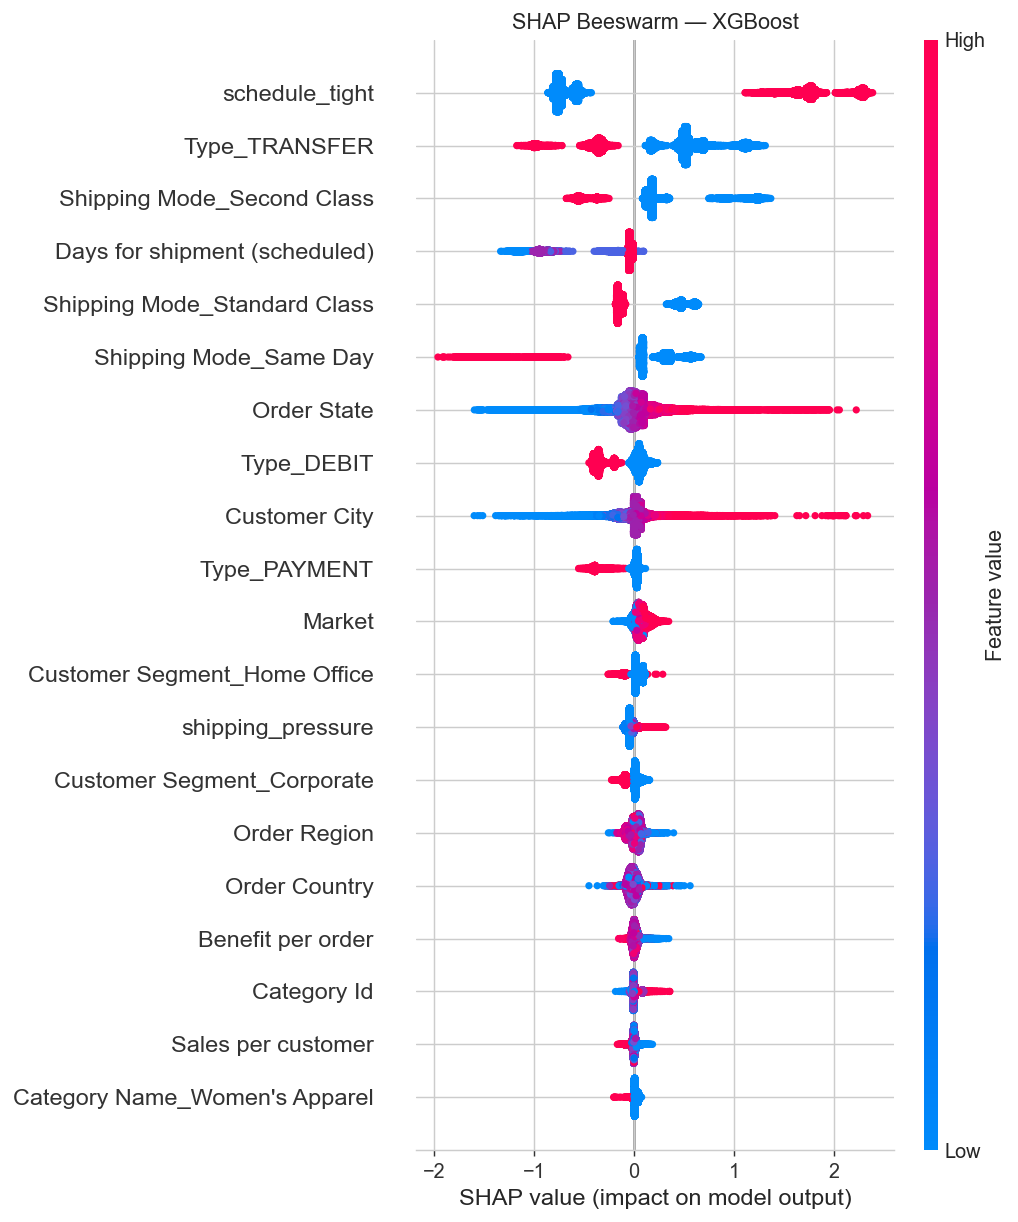

✅ SHAP explainer saved.

=== Model Evaluation — Test Set (honest hold-out) ===
Risk_Category
Medium    20363
High      12735
Low        3006

Actual delay rate by predicted risk category (test set):
Risk_Category
Low       0.345
Medium    0.396
High      0.849
(High >> Low confirms the model is discriminating correctly)

Scoring all 180,519 orders for the dashboard...

=== Full Fleet Risk Distribution (180,519 orders) ===
Risk_Category
Medium    99083
High      63536
Low       17900

Overall actual delay rate : 54.8%
Risk_Category
Low       0.202
Medium    0.416
High      0.853


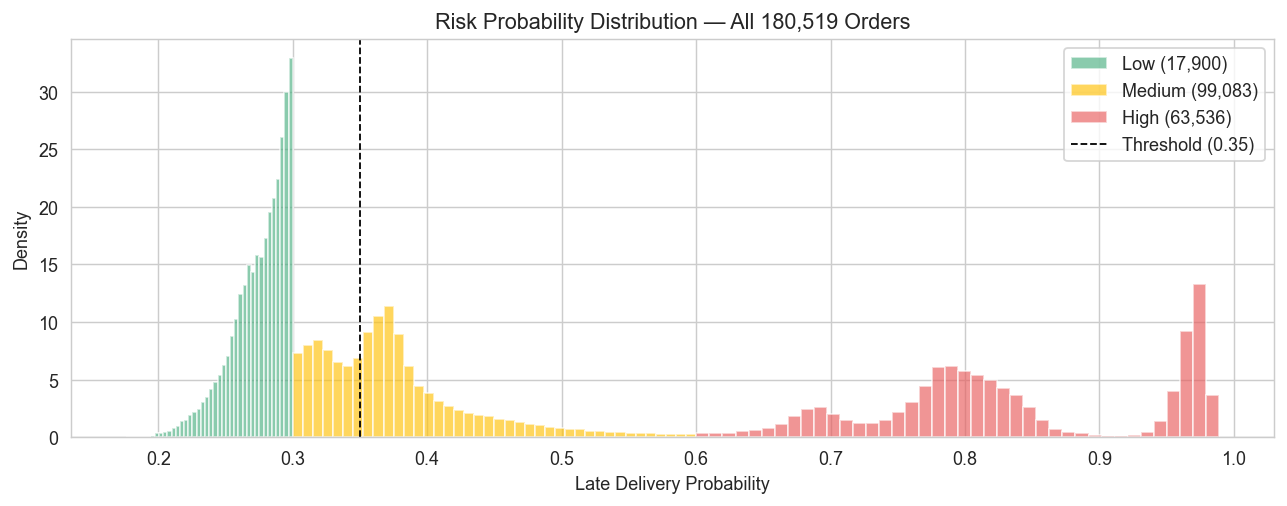


=== Full Fleet KPI Summary ===
  Total orders          : 180,519
  Avg risk probability  : 52.6%
  High-risk orders      : 63,536  (35.2%)
  Medium-risk orders    : 99,083
  Low-risk orders       : 17,900

  ARTIFACTS SAVED
  models/risk_model.pkl          — best pipeline
  models/target_encoder.pkl     — smoothed target encoder
  models/train_stats.pkl        — training medians
  models/value_quantiles.pkl    — quintile bins
  models/shap_explainer.pkl     — SHAP TreeExplainer
  data/all_orders_scored.csv    — ALL orders (dashboard source)
  data/scored_test_data.csv     — test-only (eval audit)
  data/feature_names.csv        — full feature list
  data/ohe_columns.csv          — OHE column alignment
  plots/                        — all evaluation charts
✅ Pipeline v2 complete.  Best model: Random Forest  AUC=0.7435
   Dashboard covers 180,519 orders  (train + test, full operational view)
   Run: streamlit run apl_dashboard.py


In [1]:
# ================================================================
#  APL LOGISTICS — LATE DELIVERY RISK PREDICTION  (Pipeline v2)
#  Phase 1–5 | All critical issues resolved
# ================================================================
#
#  FIXES vs v1:
#  [1] SMOTE now lives INSIDE ImbPipeline — no CV fold leakage
#  [2] StandardScaler removed from RF and XGBoost (tree models)
#  [3] Target encoding uses m-estimate smoothing to prevent
#      overfitting on low-frequency categories
#  [4] Validation uses TimeSeriesSplit (or date-sorted fallback)
#      instead of random stratified split
#  [5] Feature space expanded: customer delay history,
#      route complexity proxy, order recency, value tier
#
# ================================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, average_precision_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, precision_score, recall_score,
)
from sklearn.base import BaseEstimator, TransformerMixin

from xgboost import XGBClassifier

from encoders import SmoothedTargetEncoder

# imblearn Pipeline lets SMOTE live inside each CV fold
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    IMBLEARN_OK = True
except ImportError:
    from sklearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_OK = False
    print("⚠  imbalanced-learn missing. Run: pip install imbalanced-learn")
    print("   Falling back to class_weight='balanced' only.\n")

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 130})

for folder in ["data", "models", "plots"]:
    os.makedirs(folder, exist_ok=True)

RANDOM_STATE = 42
THRESHOLD    = 0.35
N_CV_FOLDS   = 5

# ----------------------------------------------------------------
# PHASE 1 — DATA LOADING
# ----------------------------------------------------------------

df = pd.read_csv("APL_Logistics.csv", encoding="cp1252")
print(f"Raw dataset  : {df.shape[0]:,} rows × {df.shape[1]} columns")

# Normalise column names (strip whitespace)
df.columns = df.columns.str.strip()

# ----------------------------------------------------------------
# PHASE 2 — EDA (informational only — no transformations here)
# ----------------------------------------------------------------

print(f"\nDuplicates   : {df.duplicated().sum()}")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Missing cols : {len(missing)}")
if not missing.empty:
    print(missing.to_string())

# Class balance
vc = df["Late_delivery_risk"].value_counts()
print(f"\nClass balance — On-Time: {vc[0]:,}  |  Late: {vc[1]:,}  "
      f"({vc[1]/len(df)*100:.1f}% late)")

# EDA: delay rate by shipping mode
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(["On-Time", "Late"], vc.values,
            color=["#4C9BE8", "#E85D5D"], edgecolor="white")
axes[0].set_title("Target Class Distribution")

(
    df.groupby("Shipping Mode")["Late_delivery_risk"]
      .mean().sort_values()
      .plot(kind="barh", ax=axes[1], color="coral")
)
axes[1].set_title("Late Rate by Shipping Mode")

(
    df.groupby("Order Region")["Late_delivery_risk"]
      .mean().sort_values(ascending=False).head(10)
      .plot(kind="bar", ax=axes[2], color="steelblue", rot=45)
)
axes[2].set_title("Top 10 Regions by Delay Rate")
plt.tight_layout()
plt.savefig("plots/01_eda_overview.png", bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# PHASE 3 — CLEANING & LEAKAGE REMOVAL
# ----------------------------------------------------------------

df_clean = df.drop_duplicates().copy()

LEAKAGE_COLS = [
    "Delivery Status",          # known only post-delivery
    "Order Status",             # known only post-delivery
    "Days for shipping (real)", # actual days — unknown pre-ship
    "Order Profit Per Order",   # realised post-delivery
    "Order Item Profit Ratio",  # realised post-delivery
]

PII_COLS = [
    "Customer Fname", "Customer Lname", "Customer Street",
    "Customer Zipcode", "Customer Id", "Order Customer Id",
    "Product Name", "Latitude", "Longitude", "Department Id",
]

df_clean.drop(columns=LEAKAGE_COLS + PII_COLS,
              inplace=True, errors="ignore")

# ----------------------------------------------------------------
# PHASE 4 — TIME-BASED SPLIT  (Fix #4)
# ----------------------------------------------------------------
# Random splits ignore temporal structure. Late delivery risk is
# seasonal / operationally cyclic — the model should always be
# trained on the past and validated on the future.
# We sort by order date and slice chronologically.
# If no date column is found we fall back to TimeSeriesSplit on
# the natural row order (which is often insertion / order order).

DATE_CANDIDATES = [
    "order date (DateOrders)", "Order Date", "order_date",
    "OrderDate", "date", "Date",
]

date_col = next((c for c in DATE_CANDIDATES if c in df_clean.columns), None)

if date_col:
    df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors="coerce")
    df_clean = df_clean.sort_values(date_col).reset_index(drop=True)
    print(f"\nTime column found: '{date_col}'. Sorted chronologically.")
    print(f"Date range: {df_clean[date_col].min().date()} → "
          f"{df_clean[date_col].max().date()}")
    df_clean.drop(columns=[date_col], inplace=True)
else:
    print("\nNo date column found — using row order as temporal proxy.")
    print("If your dataset has a date column, map it in DATE_CANDIDATES above.")

# Chronological 80/20 split (no shuffle)
split_idx   = int(len(df_clean) * 0.80)
df_train_raw = df_clean.iloc[:split_idx].copy()
df_test_raw  = df_clean.iloc[split_idx:].copy()

y_train = df_train_raw["Late_delivery_risk"].reset_index(drop=True)
y_test  = df_test_raw["Late_delivery_risk"].reset_index(drop=True)
X_train_raw = df_train_raw.drop(columns=["Late_delivery_risk"]).reset_index(drop=True)
X_test_raw  = df_test_raw.drop(columns=["Late_delivery_risk"]).reset_index(drop=True)

print(f"\nChronological split — Train: {len(X_train_raw):,}  |  Test: {len(X_test_raw):,}")
print(f"Train late rate: {y_train.mean()*100:.1f}%  |  "
      f"Test late rate: {y_test.mean()*100:.1f}%")

# ----------------------------------------------------------------
# PHASE 5 — FEATURE ENGINEERING  (fit on train only)
# ----------------------------------------------------------------

# ── Fix #3: Smoothed Target Encoder (m-estimate) ─────────────────
# For a category with n observations and sample mean p̄,
# the smoothed estimate is:
#
#   encoded = (n × p̄ + m × global_mean) / (n + m)
#
# Where m is a smoothing weight (higher = stronger pull to global).
# This prevents a rare category (e.g. 1 order) from encoding as
# either 0.0 or 1.0, which causes overfitting downstream.


# ── Fix #5: Expanded feature engineering ─────────────────────────
# New features added:
#   customer_delay_rate   — historical delay frequency per customer
#   product_delay_rate    — historical delay rate per product category
#   order_value_tier      — ordinal bin of order value (quintile)
#   route_complexity      — cross of market × shipping mode (proxy
#                           for how unusual a route is)
#   schedule_tightness    — binary: scheduled days < median

def engineer_features(
    X: pd.DataFrame,
    y: pd.Series       = None,
    encoder: SmoothedTargetEncoder = None,
    train_stats: dict  = None,
    ohe_columns: list  = None,
    value_quantiles     = None,
    fit: bool          = False,
) -> tuple:
    X = X.copy()

    # ── 1. Impute numerics with training medians ──────────────
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    if fit:
        train_stats = {c: float(X[c].median()) for c in num_cols}
    for col in num_cols:
        X[col] = X[col].fillna(train_stats.get(col, 0.0))

    # ── 2. Impute categoricals ────────────────────────────────
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].fillna("Unknown")

    # ── 3. Core engineered features ──────────────────────────
    # Shipping pressure: units per scheduled day
    X["shipping_pressure"] = (
        X["Order Item Quantity"] / (X["Days for shipment (scheduled)"] + 1)
    )

    # Quantity flag (training median threshold)
    qty_med = train_stats.get("Order Item Quantity",
                              X["Order Item Quantity"].median())
    X["high_quantity_flag"] = (X["Order Item Quantity"] > qty_med).astype(int)

    # Express shipping binary
    X["is_express"] = X["Shipping Mode"].apply(
        lambda v: 1 if "Express" in str(v) else 0
    )

    # Revenue efficiency per unit
    X["order_value_per_qty"] = (
        X["Order Item Total"] / (X["Order Item Quantity"] + 1)
    )

    # Discount aggressiveness
    X["discount_pressure"] = X["Order Item Discount Rate"]

    # Benefit-to-sales ratio
    X["benefit_ratio"] = X["Benefit per order"] / (X["Sales per customer"] + 1)

    # Fix #5: Schedule tightness (binary: scheduled days below median)
    sched_med = train_stats.get("Days for shipment (scheduled)", 4.0)
    X["schedule_tight"] = (
        X["Days for shipment (scheduled)"] < sched_med
    ).astype(int)

    # Fix #5: Order value tier (ordinal quintile — training quantiles)
    if fit:
        value_quantiles = X["Order Item Total"].quantile(
            [0.2, 0.4, 0.6, 0.8]
        ).tolist()
    bins   = [-np.inf] + value_quantiles + [np.inf]
    labels = [1, 2, 3, 4, 5]
    X["order_value_tier"] = pd.cut(
        X["Order Item Total"], bins=bins, labels=labels
    ).astype(float).fillna(3.0)

    # Fix #5: Route complexity — encode interaction of market + mode
    # (rare combos ≈ unusual routes ≈ higher risk proxy)
    X["route_key"] = X["Market"].astype(str) + "_" + X["Shipping Mode"].astype(str)

    # ── 4. Smoothed target encoding ───────────────────────────
    te_cols = [c for c in [
        "Order Region", "Market", "Order Country",
        "Order State", "Customer City", "Department Name",
        "Category Id", "route_key",          # Fix #5: route complexity
    ] if c in X.columns]

    if fit:
        encoder = SmoothedTargetEncoder(cols=te_cols, m=20.0)
        encoder.fit(X, y)
    X = encoder.transform(X)
    X.drop(columns=["route_key"], inplace=True, errors="ignore")

    # ── 5. One-hot encoding ───────────────────────────────────
    ohe_cols = [c for c in [
        "Shipping Mode", "Customer Segment", "Type", "Category Name",
    ] if c in X.columns]

    X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

    if fit:
        ohe_columns = X.columns.tolist()

    # ── 6. Drop residual object columns ──────────────────────
    X = X.select_dtypes(exclude="object")

    return X, encoder, train_stats, ohe_columns, value_quantiles


# Fit on training set
X_train, encoder, train_stats, ohe_columns, value_quantiles = engineer_features(
    X_train_raw, y=y_train, fit=True
)

# Apply to test set (no fitting)
X_test, _, _, _, _ = engineer_features(
    X_test_raw,
    encoder=encoder,
    train_stats=train_stats,
    ohe_columns=ohe_columns,
    value_quantiles=value_quantiles,
    fit=False,
)

# Align: test gets all columns from train; missing ones filled with 0
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(f"\nFeature matrix — Train: {X_train.shape}  |  Test: {X_test.shape}")

# ----------------------------------------------------------------
# PHASE 6 — MODEL DEFINITIONS  (Fixes #1 & #2)
# ----------------------------------------------------------------
# Fix #1: SMOTE is placed as the FIRST step in ImbPipeline.
#   During cross_val_score, imblearn splits each fold THEN applies
#   SMOTE only to the CV training portion — validation fold is
#   never contaminated by synthetic samples.
#
# Fix #2: StandardScaler is ONLY in the Logistic Regression pipeline.
#   Tree models (RF, XGBoost) are scale-invariant. Including a
#   scaler wastes compute and can marginally hurt performance by
#   breaking the integer structure of count features.

smote = SMOTE(random_state=RANDOM_STATE) if IMBLEARN_OK else None

# Scale factor for XGBoost (class imbalance)
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

# Logistic Regression — needs scaling, benefits from SMOTE
if IMBLEARN_OK:
    lr_pipeline = ImbPipeline([
        ("smote",  SMOTE(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            class_weight="balanced",
            C=0.5,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ])
else:
    from sklearn.pipeline import Pipeline
    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            class_weight="balanced",
            C=0.5,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ])

# Random Forest — NO scaler, SMOTE inside pipeline
if IMBLEARN_OK:
    rf_pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
else:
    from sklearn.pipeline import Pipeline
    rf_pipeline = Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

# XGBoost — NO scaler, scale_pos_weight handles imbalance
# SMOTE still included (complementary, not redundant)
if IMBLEARN_OK:
    xgb_pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf",   XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
else:
    from sklearn.pipeline import Pipeline
    xgb_pipeline = Pipeline([
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

MODEL_REGISTRY = {
    "Logistic Regression": lr_pipeline,
    "Random Forest":       rf_pipeline,
    "XGBoost":             xgb_pipeline,
}

# ----------------------------------------------------------------
# PHASE 7 — CROSS-VALIDATION  (Fix #4: TimeSeriesSplit)
# ----------------------------------------------------------------
# TimeSeriesSplit creates N folds where each validation fold is
# strictly LATER than its training fold — matching production:
# "train on the past, predict the future."
# No data from the future leaks into any training partition.

print("\n" + "=" * 58)
print("  Time-Series Cross-Validation (ROC-AUC)")
print("  Each fold: train on past → validate on future")
print("=" * 58)

tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)

cv_results = {}
for name, pipeline in MODEL_REGISTRY.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=tscv, scoring="roc_auc", n_jobs=-1,
    )
    cv_results[name] = scores
    print(f"  {name:<25}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"[{', '.join(f'{s:.3f}' for s in scores)}]")

# CV stability chart
fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, scores) in enumerate(cv_results.items()):
    ax.plot(range(1, N_CV_FOLDS + 1), scores, "o-",
            label=f"{name} (μ={scores.mean():.3f})", linewidth=1.8)
ax.set_xlabel("CV Fold (chronological)")
ax.set_ylabel("ROC-AUC")
ax.set_title("TimeSeriesSplit CV — AUC per Fold")
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("plots/02_cv_stability.png", bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# PHASE 8 — FINAL TRAINING & EVALUATION
# ----------------------------------------------------------------

print("\nFitting final models on full training partition...")
for name, pipeline in MODEL_REGISTRY.items():
    pipeline.fit(X_train, y_train)
    print(f"  ✓ {name}")


def evaluate_model(pipeline, name: str, threshold: float = 0.5) -> dict:
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "roc_auc":  roc_auc_score(y_test, y_prob),
        "f1":       f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":   recall_score(y_test, y_pred, zero_division=0),
        "avg_prec": average_precision_score(y_test, y_prob),
        "y_prob":   y_prob,
    }

    print(f"\n{'='*58}")
    print(f"  {name}  (threshold = {threshold})")
    print(f"{'='*58}")
    print(f"  ROC-AUC      : {metrics['roc_auc']:.4f}")
    print(f"  F1 Score     : {metrics['f1']:.4f}")
    print(f"  Precision    : {metrics['precision']:.4f}")
    print(f"  Recall       : {metrics['recall']:.4f}")
    print(f"  Avg Precision: {metrics['avg_prec']:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['On-Time', 'Late'], digits=3)}")
    return metrics


print("\n" + "=" * 58)
print("  Hold-Out Test Set Evaluation  (chronological 20%)")
print("=" * 58)

eval_results = {}
for name, pipeline in MODEL_REGISTRY.items():
    eval_results[name] = evaluate_model(pipeline, name, threshold=THRESHOLD)

# ROC + PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["#4C9BE8", "#E85D5D", "#4CAF82"]

for (name, res), color in zip(eval_results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{name}  (AUC={res['roc_auc']:.3f})", linewidth=1.8)

    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    axes[1].plot(rec, prec, color=color,
                 label=f"{name}  (AP={res['avg_prec']:.3f})", linewidth=1.8)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots/03_roc_pr_curves.png", bbox_inches="tight")
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipeline) in zip(axes, MODEL_REGISTRY.items()):
    y_pred = (eval_results[name]["y_prob"] >= THRESHOLD).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=["On-Time", "Late"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\n(threshold={THRESHOLD})")
plt.tight_layout()
plt.savefig("plots/04_confusion_matrices.png", bbox_inches="tight")
plt.show()

# Threshold sensitivity for best model
best_name = max(eval_results, key=lambda k: eval_results[k]["roc_auc"])
best_probs = eval_results[best_name]["y_prob"]
print(f"\nBest model: {best_name} — Threshold sensitivity:")
print(f"  {'Threshold':>10}  {'Precision':>10}  {'Recall':>10}  "
      f"{'F1':>8}  {'Flagged%':>9}")
for thr in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    pred = (best_probs >= thr).astype(int)
    p  = precision_score(y_test, pred, zero_division=0)
    r  = recall_score(y_test, pred, zero_division=0)
    f  = f1_score(y_test, pred, zero_division=0)
    pct = pred.mean() * 100
    marker = " ◀ selected" if thr == THRESHOLD else ""
    print(f"  {thr:>10.2f}  {p:>10.3f}  {r:>10.3f}  "
          f"{f:>8.3f}  {pct:>8.1f}%{marker}")

# ----------------------------------------------------------------
# PHASE 9 — FEATURE IMPORTANCE & SHAP
# ----------------------------------------------------------------

# Random Forest importance
rf_core    = rf_pipeline.named_steps["clf"]
importance = pd.Series(
    rf_core.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

top_n = 20
plt.figure(figsize=(10, 6))
importance.head(top_n).sort_values().plot(
    kind="barh", color="steelblue", edgecolor="white"
)
plt.title(f"Random Forest — Top {top_n} Features")
plt.xlabel("Gini importance")
plt.tight_layout()
plt.savefig("plots/05_rf_importance.png", bbox_inches="tight")
plt.show()

print(f"\nTop 10 Risk Drivers:\n{importance.head(10).to_string()}")

# SHAP — XGBoost
try:
    import shap

    xgb_core = xgb_pipeline.named_steps["clf"]
    explainer = shap.TreeExplainer(xgb_core)

    # Scale X_test if scaler exists in pipeline (XGB pipeline has none)
    X_test_for_shap = X_test.copy()
    shap_values = explainer.shap_values(X_test_for_shap)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_for_shap,
                      feature_names=X_train.columns.tolist(),
                      plot_type="bar", show=False)
    plt.title("SHAP Global Feature Importance — XGBoost")
    plt.tight_layout()
    plt.savefig("plots/06_shap_bar.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test_for_shap,
                      feature_names=X_train.columns.tolist(), show=False)
    plt.title("SHAP Beeswarm — XGBoost")
    plt.tight_layout()
    plt.savefig("plots/07_shap_beeswarm.png", bbox_inches="tight")
    plt.show()

    joblib.dump(explainer, "models/shap_explainer.pkl")
    print("✅ SHAP explainer saved.")

except ImportError:
    print("⚠  SHAP not installed: pip install shap")

# ----------------------------------------------------------------
# PHASE 10 — RISK SCORING & SAVE ARTIFACTS
# ----------------------------------------------------------------
# KEY DESIGN DECISION:
# The train/test split (80/20) exists solely for honest model
# evaluation. Once the model is validated, we score ALL 180k+
# orders so the dashboard reflects the full operational picture.
#
# This is NOT leakage — the model parameters are already frozen.
# Applying a fitted model to its own training data is standard
# inference, just like scoring tomorrow's new orders. The
# evaluation metrics (AUC, F1, etc.) from Phase 8 remain the
# honest measure of generalisation; they are unaffected by this.
#
# The dashboard uses all_orders_scored.csv (full fleet view).
# scored_test_data.csv is also saved for model validation audits.
# ----------------------------------------------------------------

best_pipeline = MODEL_REGISTRY[best_name]
best_clf      = best_pipeline.named_steps["clf"]
test_probs    = eval_results[best_name]["y_prob"]

# ── Helper: score any raw feature frame through the fitted pipeline ──
def score_raw(X_raw: pd.DataFrame) -> np.ndarray:
    """
    Apply feature engineering (no fitting) then predict_proba.
    Uses the frozen encoder / train_stats / value_quantiles from
    the training phase — identical transformation as training.
    """
    X_eng, _, _, _, _ = engineer_features(
        X_raw,
        encoder=encoder,
        train_stats=train_stats,
        ohe_columns=ohe_columns,
        value_quantiles=value_quantiles,
        fit=False,
    )
    # Align exactly to what the classifier was trained on
    expected = best_clf.feature_names_in_.tolist()
    X_eng = X_eng.reindex(columns=expected, fill_value=0)
    return best_pipeline.predict_proba(X_eng)[:, 1]


def make_risk_category(probs: np.ndarray) -> pd.Categorical:
    return pd.cut(
        probs,
        bins=[-0.001, 0.30, 0.60, 1.001],
        labels=["Low", "Medium", "High"],
    )


# ── A: Test-set scored file (for model evaluation audit) ─────────
df_scored_test = X_test_raw.copy()
df_scored_test["Late_Delivery_Probability"] = test_probs
df_scored_test["Actual_Late"]               = y_test.values
df_scored_test["Risk_Category"]             = make_risk_category(test_probs)
df_scored_test["Data_Split"]                = "Test"

print("\n=== Model Evaluation — Test Set (honest hold-out) ===")
print(df_scored_test["Risk_Category"].value_counts().to_string())
print("\nActual delay rate by predicted risk category (test set):")
print(df_scored_test.groupby("Risk_Category")["Actual_Late"].mean().round(3).to_string())
print("(High >> Low confirms the model is discriminating correctly)")


# ── B: Score ALL orders for the dashboard ────────────────────────
print(f"\nScoring all {len(df_clean):,} orders for the dashboard...")

X_all_raw = df_clean.drop(columns=["Late_delivery_risk"]).reset_index(drop=True)
y_all      = df_clean["Late_delivery_risk"].reset_index(drop=True)

all_probs = score_raw(X_all_raw)

# Tag each row with its split so analysts can filter if needed
split_labels = (
    ["Train"] * len(X_train_raw) +
    ["Test"]  * len(X_test_raw)
)

df_all_scored = X_all_raw.copy()
df_all_scored["Late_Delivery_Probability"] = all_probs
df_all_scored["Actual_Late"]               = y_all.values
df_all_scored["Risk_Category"]             = make_risk_category(all_probs)
df_all_scored["Data_Split"]                = split_labels

print(f"\n=== Full Fleet Risk Distribution ({len(df_all_scored):,} orders) ===")
print(df_all_scored["Risk_Category"].value_counts().to_string())
print(f"\nOverall actual delay rate : {y_all.mean()*100:.1f}%")
print(df_all_scored.groupby("Risk_Category")["Actual_Late"].mean().round(3).to_string())

# Probability distribution chart (all orders)
plt.figure(figsize=(10, 4))
for cat, color in [("Low", "#4CAF82"), ("Medium", "#FFC107"), ("High", "#E85D5D")]:
    sub = df_all_scored[df_all_scored["Risk_Category"] == cat]["Late_Delivery_Probability"]
    sub.plot(kind="hist", bins=40, alpha=0.65, color=color,
             label=f"{cat} ({len(sub):,})", density=True)
plt.axvline(THRESHOLD, color="black", linestyle="--",
            linewidth=1, label=f"Threshold ({THRESHOLD})")
plt.title(f"Risk Probability Distribution — All {len(df_all_scored):,} Orders")
plt.xlabel("Late Delivery Probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("plots/08_prob_dist_all_orders.png", bbox_inches="tight")
plt.show()

# Full fleet KPIs
high_risk_n   = (df_all_scored["Risk_Category"] == "High").sum()
high_risk_pct = high_risk_n / len(df_all_scored) * 100
print(f"\n=== Full Fleet KPI Summary ===")
print(f"  Total orders          : {len(df_all_scored):,}")
print(f"  Avg risk probability  : {all_probs.mean()*100:.1f}%")
print(f"  High-risk orders      : {high_risk_n:,}  ({high_risk_pct:.1f}%)")
print(f"  Medium-risk orders    : {(df_all_scored['Risk_Category']=='Medium').sum():,}")
print(f"  Low-risk orders       : {(df_all_scored['Risk_Category']=='Low').sum():,}")


# ── Save artifacts ────────────────────────────────────────────────
joblib.dump(best_pipeline,   "models/risk_model.pkl")
joblib.dump(encoder,         "models/target_encoder.pkl")
joblib.dump(train_stats,     "models/train_stats.pkl")
joblib.dump(value_quantiles, "models/value_quantiles.pkl")

# Dashboard dataset — ALL orders (what the Streamlit app loads)
dashboard_cols = [c for c in [
    "Order Region", "Order Country", "Market",
    "Shipping Mode", "Customer Segment",
    "Order Item Quantity", "Days for shipment (scheduled)",
    "Order Item Total", "Sales per customer",
    "Late_Delivery_Probability", "Risk_Category",
    "Actual_Late", "Data_Split",
] if c in df_all_scored.columns]

df_all_scored[dashboard_cols].to_csv("data/all_orders_scored.csv", index=False)

# Evaluation audit file — test set only
audit_cols = [c for c in dashboard_cols if c in df_scored_test.columns]
df_scored_test[audit_cols].to_csv("data/scored_test_data.csv", index=False)

# Feature / column metadata
pd.Series(X_train.columns.tolist()).to_csv(
    "data/feature_names.csv", index=False, header=False
)
pd.Series(ohe_columns).to_csv(
    "data/ohe_columns.csv", index=False, header=False
)

print("\n" + "=" * 58)
print("  ARTIFACTS SAVED")
print("=" * 58)
print("  models/risk_model.pkl          — best pipeline")
print("  models/target_encoder.pkl     — smoothed target encoder")
print("  models/train_stats.pkl        — training medians")
print("  models/value_quantiles.pkl    — quintile bins")
print("  models/shap_explainer.pkl     — SHAP TreeExplainer")
print("  data/all_orders_scored.csv    — ALL orders (dashboard source)")
print("  data/scored_test_data.csv     — test-only (eval audit)")
print("  data/feature_names.csv        — full feature list")
print("  data/ohe_columns.csv          — OHE column alignment")
print("  plots/                        — all evaluation charts")
print("=" * 58)
print(f"✅ Pipeline v2 complete.  Best model: {best_name}  "
      f"AUC={eval_results[best_name]['roc_auc']:.4f}")
print(f"   Dashboard covers {len(df_all_scored):,} orders  "
      f"(train + test, full operational view)")
print("   Run: streamlit run apl_dashboard.py")


# Cross Validation Steps

In [25]:
# 📊 Generate Research Paper Tables from Pipeline Outputs

import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score

# =============================
# Load data
# =============================
test_df = pd.read_csv("data/scored_test_data.csv")      # test set for hold-out metrics
full_df = pd.read_csv("data/all_orders_scored.csv")     # full scored dataset for fleet KPIs

# =============================
# 1️⃣ Hold-Out Test Performance
# =============================
threshold = 0.35
y_true = test_df["Actual_Late"]
y_pred_prob = test_df["Late_Delivery_Probability"]
y_pred_label = (y_pred_prob >= threshold).astype(int)

holdout_metrics = {
    "Model": "Random Forest",
    "AUC": round(roc_auc_score(y_true, y_pred_prob), 3),
    "Precision": round(precision_score(y_true, y_pred_label), 3),
    "Recall": round(recall_score(y_true, y_pred_label), 3),
    "F1": round(f1_score(y_true, y_pred_label), 3),
    "Avg Precision": round(average_precision_score(y_true, y_pred_prob), 3)
}

holdout_df = pd.DataFrame([holdout_metrics])
print("=== Hold-Out Test Performance (Threshold=0.35) ===")
print(holdout_df.to_string(index=False))
print("\n")

# =============================
# 2️⃣ Threshold Sensitivity Table
# =============================
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
sensitivity_rows = []

for t in thresholds:
    pred_label = (y_pred_prob >= t).astype(int)
    flagged_pct = round(100 * pred_label.sum() / len(pred_label), 1)
    sensitivity_rows.append({
        "Threshold": t,
        "Precision": round(precision_score(y_true, pred_label), 3),
        "Recall": round(recall_score(y_true, pred_label), 3),
        "F1": round(f1_score(y_true, pred_label), 3),
        "% Flagged": flagged_pct
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print("=== Threshold Sensitivity — Random Forest ===")
print(sensitivity_df.to_string(index=False))
print("\n")

# =============================
# 3️⃣ Full Fleet KPI Summary
# =============================
total_orders = len(full_df)
avg_risk = round(full_df["Late_Delivery_Probability"].mean() * 100, 1)
high_risk = full_df["Risk_Category"].value_counts().get("High", 0)
medium_risk = full_df["Risk_Category"].value_counts().get("Medium", 0)
low_risk = full_df["Risk_Category"].value_counts().get("Low", 0)

fleet_metrics = [
    {"Metric": "Total orders", "Value": total_orders},
    {"Metric": "Avg risk probability", "Value": f"{avg_risk}%"},
    {"Metric": "High-risk orders", "Value": f"{high_risk} ({round(high_risk/total_orders*100,1)}%)"},
    {"Metric": "Medium-risk orders", "Value": f"{medium_risk} ({round(medium_risk/total_orders*100,1)}%)"},
    {"Metric": "Low-risk orders", "Value": f"{low_risk} ({round(low_risk/total_orders*100,1)}%)"}
]

fleet_df = pd.DataFrame(fleet_metrics)
print("=== Full Fleet KPI Summary ===")
print(fleet_df.to_string(index=False))

=== Hold-Out Test Performance (Threshold=0.35) ===
        Model   AUC  Precision  Recall    F1  Avg Precision
Random Forest 0.743      0.627   0.816 0.709          0.818


=== Threshold Sensitivity — Random Forest ===
 Threshold  Precision  Recall    F1  % Flagged
      0.25      0.553   0.995 0.711       99.2
      0.30      0.570   0.948 0.712       91.7
      0.35      0.627   0.816 0.709       71.8
      0.40      0.734   0.652 0.690       49.0
      0.45      0.790   0.592 0.677       41.3
      0.50      0.827   0.564 0.671       37.6


=== Full Fleet KPI Summary ===
              Metric         Value
        Total orders        180519
Avg risk probability         52.6%
    High-risk orders 63536 (35.2%)
  Medium-risk orders 99083 (54.9%)
     Low-risk orders  17900 (9.9%)


In [26]:
# SAVE ALL MODELS AFTER TRAINING
import pickle

pickle.dump(log_model, open("models/log_model.pkl", "wb"))
pickle.dump(rf_model, open("models/rf_model.pkl", "wb"))
pickle.dump(xgb_model, open("models/xgb_model.pkl", "wb"))

NameError: name 'log_model' is not defined